In [3]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
 

In [4]:
netflix=pd.read_csv('netflix_titles.csv')

In [43]:
netflix.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [44]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [45]:
netflix.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [46]:
netflix[['director','cast','country']] = netflix[['director','cast','country']].fillna("Unknown")
netflix.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64

In [47]:
netflix.dropna(inplace=True)

In [9]:
print(netflix.shape)
netflix.isnull().sum()

(7770, 12)


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genres          0
description     0
dtype: int64

In [10]:
netflix.duplicated().sum()

0

In [49]:
netflix['date_added']= netflix['date_added'].apply(pd.to_datetime)

In [51]:
netflix['month_added'] = netflix['date_added'].dt.month_name()
netflix['day'] = netflix['date_added'].dt.day
#netflix['month_added'] = pd.to_datetime(netflix['date_added']).dt.month
#netflix['release_year'] = netflix['release_year'].apply(pd.to_datetime)
#netflix['turnaround'] = (netflix['date_added'] - netflix['release_year'])
#netflix['turnaround'] = netflix['turnaround'].dt.days
netflix.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,day
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",September,25
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",September,24
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,September,24
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",September,24
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,September,24


In [52]:
netflix.to_csv('UpatedNetflixNew.csv', index=False)


In [ ]:
netflix.info()

In [65]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# TF-IDF Vectorizer
vectorizer = TfidfVectorizer()
subset_listed_in = netflix['listed_in'].iloc[:500]
tfidf_matrix = vectorizer.fit_transform(subset_listed_in)

# Compute similarity (change 'description' to 'director', 'cast', etc., as needed)
similarity_matrix = cosine_similarity(tfidf_matrix)

# You can now analyze similarity_matrix for patterns

similarity_matrix


array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.63722856, ..., 0.        , 0.27279337,
        0.        ],
       [0.        , 0.63722856, 1.        , ..., 0.        , 0.10745652,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        1.        ],
       [0.        , 0.27279337, 0.10745652, ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        1.        ]])

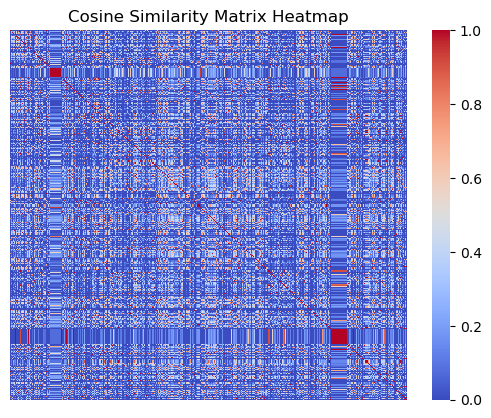

In [66]:
sns.heatmap(similarity_matrix, xticklabels=False, yticklabels=False, cmap='coolwarm')
plt.title('Cosine Similarity Matrix Heatmap')
plt.show()

In [8]:
descriptions = netflix['description'].tolist() 

In [9]:
descriptions

['As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.',
 'After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.',
 'To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war.',
 'Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series.',
 'In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life.',
 'The arrival of a charismatic young priest brings glorious miracles, ominous mysteries and renewed religious fervor to a dying town desperate to believe.',
 "Equestria's divided. But a bright-eyed hero believes Earth Ponies, Pegas

In [10]:
import spacy

# Load the pre-trained spaCy model
nlp = spacy.load("en_core_web_sm")

# Assuming 'descriptions' is a list of all descriptions from the dataset
for description in descriptions:
    doc = nlp(description)
    for entity in doc.ents:
        print(entity.text, entity.label_)


ModuleNotFoundError: No module named 'spacy'

In [11]:
pip install spacy

  Obtaining dependency information for spacy from https://files.pythonhosted.org/packages/92/fb/d1f0605e1e8627226c6c96053fe1632e9a04a3fbcd8b5d715528cb95eb97/spacy-3.7.4-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for spacy-legacy<3.1.0,>=3.0.11 from https://files.pythonhosted.org/packages/c3/55/12e842c70ff8828e34e543a2c7176dac4da006ca6901c9e8b43efab8bc6b/spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata
  Obtaining dependency information for spacy-loggers<2.0.0,>=1.0.0 from https://files.pythonhosted.org/packages/33/78/d1a1a026ef3af911159398c939b1509d5c36fe524c7b644f34a5146c4e16/spacy_loggers-1.0.5-py3-none-any.whl.metadata
  Obtaining dependency information for murmurhash<1.1.0,>=0.28.0 from https://files.pythonhosted.org/packages/71/46/af01a20ec368bd9cb49a1d2df15e3eca113bbf6952cc1f2a47f1c6801a7f/murmurhash-1.0.10-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for cymem<2.1.0,>=2.0.2 from https://files.pythonhosted.org/packages/c1/c3/dd

In [15]:
!python -m spacy download en_core_web_sm




     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.1/12.8 MB 1.6 MB/s eta 0:00:08
     -- ------------------------------------- 0.7/12.8 MB 6.6 MB/s eta 0:00:02
     ------ --------------------------------- 2.0/12.8 MB 12.7 MB/s eta 0:00:01
     ------------ --------------------------- 3.9/12.8 MB 19.3 MB/s eta 0:00:01
     ------------------- -------------------- 6.1/12.8 MB 24.5 MB/s eta 0:00:01
     ------------------------ --------------- 7.9/12.8 MB 26.5 MB/s eta 0:00:01
     ---------------------------- ----------- 9.1/12.8 MB 26.5 MB/s eta 0:00:01
     ----------------------------------- --- 11.6/12.8 MB 40.9 MB/s eta 0:00:01
     --------------------------------------  12.8/12.8 MB 40.9 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 36.4 MB/s eta 0:00:00
[+] Download and installation successful
You can now load 

In [16]:
import spacy

# Load the pre-trained spaCy model
nlp = spacy.load("en_core_web_sm")

# Assuming 'descriptions' is a list of all descriptions from the dataset
for description in descriptions:
    doc = nlp(description)
    for entity in doc.ents:
        print(entity.text, entity.label_)


Kirsten Johnson PERSON
Mehdi ORG
the Orleans Justice Center ORG
New Orleans GPE
India GPE
Equestria PERSON
Earth LOC
Pegasi GPE
Unicorns ORG
Ghana GPE
American NORP
10-week DATE
U.K. GPE
Anti-Mafia WORK_OF_ART
Bangkok GPE
Tetê PERSON
Bengaluru GPE
four CARDINAL
daily DATE
post-WWII EVENT
Otto Skorzeny PERSON
Hitler PERSON
Spain GPE
Strangers Diego PERSON
Mexico GPE
the 1960s DATE
Holocaust ORG
Nazis NORP
Spain GPE
WWII EVENT
the late 1970s DATE
America GPE
13th-century DATE
Turkish NORP
days DATE
Cory Carson PERSON
five CARDINAL
three CARDINAL
Chicago Party ORG
Aunt Diane PERSON
Maeve ORG
Hundreds CARDINAL
Tayo PERSON
three CARDINAL
Marseille ORG
Chuck PERSON
Bruce Lee PERSON
Shaolin PRODUCT
Dholakpur NORP
Adam PERSON
Grayskull GPE
Eternia GPE
Skeletor PERSON
Amity Island LOC
Four years DATE
Martin Brody PERSON
Amity Island LOC
Ellen Brody PERSON
Amity Island LOC
Caribbean LOC
Robin Wiltshire's PERSON
Westerns PERSON
CIA ORG
Matt Weston PERSON
Five CARDINAL
2016 DATE
one day DATE
Great

Allspark ORG
first ORDINAL
four decades DATE
two CARDINAL
Cali GPE
South Los Angeles GPE
Two CARDINAL
two CARDINAL
two CARDINAL
Europe LOC
the Mighty Express ORG
The Plastic Cup EVENT
Boyz PERSON
Atlanta GPE
Mossad ORG
Tehran GPE
Rachel PERSON
Wyatt Earp LOC
Doc Holliday PERSON
the Wild West LOC
German NORP
Django PERSON
America GPE
Olympics EVENT
Maddy Cornell ORG
South African NORP
Broadway FAC
New York City GPE
Two CARDINAL
millions CARDINAL
overnight TIME
Kingdom GPE
Eternia GPE
Teela PERSON
Universe ORG
80s DATE
Revelation ORG
Kevin Smith PERSON
three CARDINAL
1965 DATE
'70s DATE
Boston GPE
Bheem PERSON
Bheem PERSON
Dholakpur GPE
Ganesha PERSON
Dholakpur PERSON
Ganesh ORG
Krishna GPE
Maayandri ORG
Can Bheem PERSON
Maayandri LOC
Krishna GPE
Bheem PERSON
Pataliputra ORG
Bheem PERSON
Africa LOC
Valhalla PRODUCT
Vikings, Bheem ORG
Bheem PERSON
Incas GPE
Japan GPE
two CARDINAL
Bheem PERSON
Hanuman PRODUCT
Bheem PERSON
Dholakpur PERSON
Bheem PERSON
Krishna GPE
Bheem ORG
African NORP
Chh

Katla PERSON
one CARDINAL
Taliban ORG
First Nations ORG
Canada GPE
Istanbul GPE
Anatolian NORP
Max PERSON
Nono PERSON
Berlin GPE
Beijing GPE
Ander PERSON
summer DATE
Alexis PERSON
East LA LOC
South African NORP
St. Petersburg GPE
Tony Stark PERSON
Avengers NORP
the day DATE
two CARDINAL
Nadia GPE
Guzmán PERSON
Spain GPE
Pacific LOC
1971 DATE
anti-Vietnam War "Free the Army EVENT
two CARDINAL
Power Rangers ORG
Earth LOC
Daisy PERSON
Cole PRODUCT
36 hours TIME
American NORP
Vietnam GPE
Jeff Foxworthy PERSON
five CARDINAL
Naoki Higashida's PERSON
Metallica PERSON
10 years later DATE
"Bling Empire WORK_OF_ART
Joel Kim Booster PERSON
Ralph Macchio PERSON
William Zabka PERSON
Season 3 DATE
Bill Burr PERSON
F Is for Family WORK_OF_ART
three CARDINAL
third ORDINAL
Whitney Cummings FAC
Five CARDINAL
Arsène Lupin PERSON
Assane Diop PERSON
India GPE
Manila GPE
Alexandra Trese PERSON
Trese NORP
Filipino LANGUAGE
Malcolm PERSON
three CARDINAL
Beirut GPE
three CARDINAL
the night before TIME
Europe L

two CARDINAL
Nobel Peace Prize WORK_OF_ART
Malala Yousafzai PERSON
her lake house FAC
Scorch Supernova PERSON
Chongqing GPE
Japanese NORP
U.S. GPE
Chinese NORP
the summer DATE
Philadelphia GPE
Los Angeles GPE
Lotte PERSON
1960s DATE
Paris GPE
Claude PERSON
Los Angeles GPE
England GPE
one CARDINAL
India GPE
three CARDINAL
Ferrari PERSON
Lina GPE
Beckett PERSON
Rowan GPE
Alaskan NORP
Lucis GPE
Kingsglaive NORP
Niflheim PERSON
Lucis PERSON
L.A. GPE
Elle Woods FAC
Harvard Law School ORG
Argentina GPE
Colombia GPE
five CARDINAL
South America's LOC
French NORP
Britain GPE
Cockney PRODUCT
Dan Jones PERSON
Britain GPE
Japan GPE
1590 DATE
Wandering ORG
Skull Castle ORG
Bird ORG
360º CARDINAL
Japan GPE
1590 DATE
Wandering ORG
Skull Castle ORG
360º CARDINAL
Japan GPE
1590 DATE
Wandering ORG
Skull Castle ORG
360º CARDINAL
Mars LOC
Rico LOC
Yura PERSON
two CARDINAL
7th-century DATE
the Indian Sea LOC
Polish NORP
Wladyslaw Szpilman PERSON
Nazi NORP
World War II EVENT
White Boy Rick WORK_OF_ART
FBI O

Love WORK_OF_ART
Rango GPE
the year DATE
2020 DATE
Black Mirror WORK_OF_ART
Dakar PERSON
Neige PERSON
the Indian Army’s ORG
Frizzle PERSON
New Year's Eve EVENT
the same night TIME
eight CARDINAL
Bridgerton PERSON
London GPE
Julia Quinn's PERSON
Earth LOC
the year DATE
Emak ORG
Hong Kong GPE
two CARDINAL
Filipino NORP
daily DATE
Earth LOC
first ORDINAL
Arctic LOC
Earth LOC
1987 DATE
Taiwan GPE
Jia-han PERSON
Birdy LOC
homophobia ORG
Hardin GPE
second ORDINAL
Bawdy ORG
London Hughes ORG
Seoul GPE
Seven CARDINAL
Six CARDINAL
One CARDINAL
Qlimax PERSON
the Rhyme Time Town ORG
Timmy PERSON
Bitzer ORG
Pidsley ORG
Shirley PERSON
Shaun PERSON
Timmy PERSON
Ariana Grande ORG
London GPE
Two CARDINAL
Rhys Nicholson ORG
Dagny Taggart PERSON
Johanne PERSON
24-day DATE
Christmas DATE
Chicago GPE
1927 DATE
Ma Rainey PERSON
Davis PERSON
Denzel Washington ORG
George C. Wolfe PERSON
August DATE
Wilson ORG
Mukhsin PERSON
10-year-old DATE
two CARDINAL
first ORDINAL
four CARDINAL
Christmas DATE
one CARDINAL

...

Three CARDINAL
1992 DATE
Rodney King PERSON
Buddy Holly ORG
Ritchie Valens PERSON
two CARDINAL
Ludovico GPE
Federica GPE
three CARDINAL
Bibi PERSON
Junior PERSON
Ludoviquito PERSON
Ciudad P. Luche PERSON
Yolanda GPE
Griselda Blanco PERSON
Pablo Escobar's ORG
Rajesh PERSON
Shankar PERSON
Rajesh PERSON
Shankar PERSON
American NORP
Hong Kong GPE
Kort PERSON
Allie PERSON
Colombian NORP
Lady Tabares PERSON
four CARDINAL
the Women's Land Army ORG
the Hoxley Estate FAC
WWII EVENT
CIA ORG
CIA ORG
Mexican NORP
$50 million MONEY
Fire Island LOC
the off-season DATE
evening TIME
Joanna PERSON
Michael PERSON
French NORP
Real Madrid ORG
Karim Benzema PERSON
Adolf Hitler's PERSON
Hitler PERSON
Anna PERSON
February 29 DATE
Quigley PERSON
Leap, Lily ORG
Tad PERSON
Letter Factory ORG
Axel ORG
LeapFrog ORG
Max PERSON
Numberland GPE
English LANGUAGE
four CARDINAL
millions CARDINAL
Earth LOC
30,000 feet QUANTITY
two CARDINAL
Three CARDINAL
Lei Ying PERSON
Tieh Hon PERSON
Ti Tan PERSON
Yunnan GPE
Olivia GPE

Nazi Germany's GPE
Chilean NORP
Pablo Neruda ORG
Los Angeles' GPE
2012 DATE
Newtown GPE
Connecticut GPE
Las Vegas GPE
Cris PERSON
a few minutes TIME
FBI ORG
three CARDINAL
Los Angeles GPE
Britain GPE
fed ORG
North Carolina GPE
Paul Flanner PERSON
Kenichi Mitsuba's PERSON
Kanzo Hattori PERSON
Venus De Milo PERSON
three CARDINAL
Kate PERSON
Afghanistan GPE
Norwegian Special Forces ORG
first ORDINAL
Margaret Hale PERSON
18-year-old DATE
avian NORP
Astrophysicists NORP
Earth LOC
Thirty years DATE
Chernobyl GPE
Chinese NORP
decades DATE
Cassini PERSON
Saturn PRODUCT
Earth LOC
Greenland GPE
Australia GPE
2017 DATE
13,000-year-old DATE
America GPE
Nazi NORP
Lithuania GPE
Jewish NORP
18th-century DATE
Flint GPE
Michigan GPE
centuries DATE
12 CARDINAL
Thailand GPE
Two CARDINAL
Curiosity ORG
NOVA ORG
Mars LOC
four CARDINAL
the magical summer of 1970 DATE
the Hall-of-Fame FAC
Chicago GPE
John Lennon PERSON
Julia PERSON
German NORP
Mexican NORP
Auschwitz PRODUCT
the '90s DATE
Italy GPE
night TIME


The Denver Post ORG
Two CARDINAL
India GPE
Thailand GPE
fifth ORDINAL
32-year-old DATE
creepy NORP
Belle GPE
Emma PERSON
Mielle GPE
Indian NORP
15k MONEY
just 5 days DATE
Hank Lawson PERSON
New York's GPE
Maribel PERSON
Maribel PERSON
Mexico GPE
one CARDINAL
Bronx GPE
Sarah PERSON
California GPE
Ganpat PERSON
Sparks ORG
one CARDINAL
three CARDINAL
1920s DATE
Hawaii GPE
Japan GPE
Russell PERSON
four CARDINAL
Russell Peters' PERSON
Russell Peters PERSON
Sydney GPE
Australia GPE
Stanley Kubrick PERSON
Emilio D'Alessandro PERSON
non-materialistic NORP
Italian NORP
Gianfranco Rosi ORG
two years DATE
Rome GPE
Sadie Mitchell PERSON
decades ago DATE
Hindi GPE
one CARDINAL
afternoon TIME
Kolkata GPE
two CARDINAL
the Egyptian revolution of EVENT
2011 DATE
one CARDINAL
years DATE
three CARDINAL
Samir PERSON
Biblical ORG
Samson ORG
Israelite ORG
Can Bheem PERSON
one CARDINAL
Italy GPE
Liri Valley LOC
San Pietro GPE
Urmila PERSON
Shrikant PERSON
Sai PERSON
Santa ORG
Nicolas PERSON
Santa Claus PERSO

1937 DATE
Spanish NORP
Ramón PERSON
Soviet NORP
Belgian NORP
Leon Trotsky PERSON
Mexico GPE
Young Ulises PERSON
one CARDINAL
Four CARDINAL
Depression-era DATE
New Orleans GPE
Eric Stoner PERSON
Cincinnati Kid PERSON
Lancey WORK_OF_ART
The Man" Howard WORK_OF_ART
three CARDINAL
Marcus du Sautoy PERSON
Earth LOC
America GPE
8-year-old DATE
Robin Wright PERSON
Catholic NORP
Thirtysomething ORG
Jae-yeong PERSON
One year DATE
Eric Draven PERSON
Draven GPE
Fergus ORG
Jody PERSON
Jody PERSON
Nova Scotia ORG
two CARDINAL
20-year DATE
Srintil LANGUAGE
Indonesian NORP
Jen PERSON
Gelfling GPE
the Crystal of Truth ORG
Mumbai GPE
six CARDINAL
Tommy Caldwell PERSON
Kevin Jorgeson PERSON
Two CARDINAL
Boston GPE
one CARDINAL
Irish NORP
Argentina GPE
Five CARDINAL
Saturday DATE
Rome GPE
William Friedkin PERSON
91-year-old DATE
Italian NORP
three CARDINAL
Ente Isla PERSON
Satan DATE
Alciel PERSON
modern-day DATE
Tokyo GPE
DuPont ORG
decades DATE
Teflon PRODUCT
Tom Seymour's PERSON
Years later DATE
1866 

KeyboardInterrupt: 

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

# Assuming 'descriptions' is a list of all descriptions from the dataset
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(descriptions)

# Convert to array and get the sum of each word across all descriptions
word_count = X.toarray().sum(axis=0)

# Mapping words to their counts
word_freq = dict(zip(vectorizer.get_feature_names_out(), word_count))

# Sort by frequency
sorted_word_freq = sorted(word_freq.items(), key=lambda item: item[1], reverse=True)

# Display most common words
print(sorted_word_freq[:10])


[('life', 845), ('young', 729), ('new', 709), ('family', 635), ('world', 570), ('man', 538), ('love', 504), ('woman', 486), ('friends', 445), ('series', 396)]


In [18]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

# Assuming 'descriptions' is a list of all descriptions from the dataset
sentiments = [sia.polarity_scores(description) for description in descriptions]

# Example: print sentiment for the first description
print(sentiments[0])


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...


{'neg': 0.123, 'neu': 0.791, 'pos': 0.085, 'compound': -0.296}


In [19]:
from sklearn.decomposition import LatentDirichletAllocation

# TF-IDF vectorization was already shown above with TfidfVectorizer
# Let's use those results here

# Fit LDA model
lda = LatentDirichletAllocation(n_components=5, random_state=0)  # Adjust n_components for the number of topics
lda.fit(tfidf_matrix)

# Display topics
for i, topic in enumerate(lda.components_):
    print(f"Top words for topic {i}:")
    print([vectorizer.get_feature_names_out()[index] for index in topic.argsort()[-10:]])
    print("\n")


Top words for topic 0:
['tomlinson', 'ancestral', 'yuta', 'hissrich', 'hoofer', 'infertile', 'ordinary', 'andrés', 'traumatic', 'tom']


Top words for topic 1:
['audition', 'butter', 'enabling', 'drilling', 'prices', 'dorms', 'dynasty', 'complexity', 'gains', '12']


Top words for topic 2:
['bobbleheads', 'druglord', 'grumpy', 'donkey', 'homeowners', 'deer', 'andrés', 'spoken', 'tom', 'expatriate']


Top words for topic 3:
['sculptors', 'mma', 'totalitarian', 'ordinary', 'scandinavia', 'persuades', 'water', 'andrés', 'tom', 'ikari']


Top words for topic 4:
['communism', 'videotaping', 'hoofer', 'traumatic', 'yuta', 'infertile', 'ordinary', 'andrés', 'totalitarian', 'tom']




In [21]:
netflix['country'].value_counts().sum()

7976

In [24]:

netflix["fr"]= netflix["country"].str.contains("France", na=False)
is_fr = netflix["fr"]== True
msk_fr= netflix[is_fr]

netflix["can"]= netflix["country"].str.contains("Canada", na=False)
is_can = netflix["can"]== True
msk_can= netflix[is_can]

#make a mask for india in country
netflix["ind"]= netflix["country"].str.contains("India", na=False)
is_ind = netflix["ind"]== True
msk_ind= netflix[is_ind]

#make a mask for united states in country
netflix["US"]= netflix["country"].str.contains("United States", na=False)
is_us = netflix["US"]== True
msk_us= netflix[is_us]
#make a mask for uk in country
netflix["UK"]= netflix["country"].str.contains("United Kingdom", na=False)
is_uk = netflix["UK"]== True
msk_uk= netflix[is_uk]

In [25]:
msk_top5= pd.concat([msk_uk, msk_can, msk_us, msk_fr, msk_ind])
msk_top5.shape

(6380, 17)

In [38]:
def find_season(x):
    
    if x == 12.0 or x==1.0 or x==2.0:
        return 'Winter'
    elif x == 3.0 or  x==4.0 or x==5.0:
        return 'Spring'
    elif x == 6.0 or x==7.0 or x==8.0:
        return 'Summer'
    elif x == 9.0 or x==10.0 or x==11.0:
        return 'Autumn'

In [37]:
msk_top5['season'] =msk_top5['month_added'].apply(find_season)

KeyError: 'month_added'

In [28]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
 12  can           8807 non-null   bool  
 13  ind           8807 non-null   bool  
 14  US            8807 non-null   bool  
 15  UK            8807 non-null   bool  
 16  fr            8807 non-null   bool  
dtypes: bool(5), int64(1), object(11)
memory usage: 868.8+ KB


In [30]:
netflix['date_added'] = pd.to_datetime(netflix['date_added'].str.strip(), format='%B %d, %Y')
netflix['month_added'] = pd.to_datetime(netflix['date_added']).dt.month

In [32]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  can           8807 non-null   bool          
 13  ind           8807 non-null   bool          
 14  US            8807 non-null   bool          
 15  UK            8807 non-null   bool    

In [33]:
msk_top5= pd.concat([msk_uk, msk_can, msk_us, msk_fr, msk_ind])
msk_top5.shape

(6380, 17)

In [39]:
msk_top5['season'] =msk_top5['month_added'].apply(find_season)

KeyError: 'month_added'

In [35]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,can,ind,US,UK,fr,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",False,False,True,False,False,9.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",False,False,False,False,False,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,False,False,False,False,False,9.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",False,False,False,False,False,9.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,False,True,False,False,False,9.0


In [47]:
'month_added' in msk_top5.columns

False

In [43]:
msk_top5= pd.concat([msk_uk, msk_can, msk_us, msk_fr, msk_ind])

In [44]:
def find_season(x):
    
    if x == 12 or x==1 or x==2:
        return 'Winter'
    elif x == 3 or  x==4 or x==5:
        return 'Spring'
    elif x == 6 or x==7 or x==8:
        return 'Summer'
    elif x == 9 or x==10 or x==11:
        return 'Autumn'

In [48]:
msk_top5['season'] =netflix['month_added'].apply(find_season)

In [49]:
msk_top5['season'].value_counts()

season
Autumn    1684
Winter    1648
Summer    1539
Spring    1502
Name: count, dtype: int64

In [51]:
msk_winter= msk_top5[msk_top5['season']== 'Winter']
msk_autumn= msk_top5[msk_top5['season']== 'Autumn']
msk_summer= msk_top5[msk_top5['season']== 'Summer']
msk_spring= msk_top5[msk_top5['season']== 'Spring']

C:\Users\ASUS\AppData\Local\Temp\ipykernel_292\4017898535.py:5: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


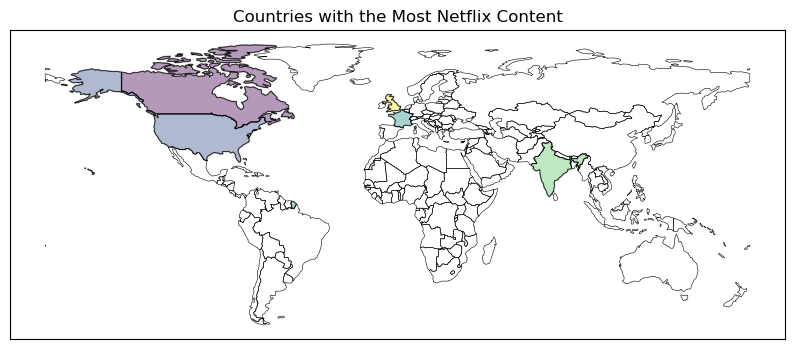

In [55]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the world map
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Now proceed with your code
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
drop_idxs = world["continent"].isin([
    "Antarctica",
    "Seven seas (open ocean)"
])

top5_names = [
    "India",
    "United States of America",
    "United Kingdom",
    "France",
    "Canada"
]

countries = world[
    world["name"].isin(top5_names)
]

ax.set_xticks([])
ax.set_yticks([])

countries.plot(
    ax=ax,
    cmap="viridis",
    edgecolor="black",
    alpha=0.4
)

# Ensure to redefine 'world' again if it's modified before plotting the boundaries
world = world.drop(world[drop_idxs].index)

world.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.4
)

plt.title("Countries with the Most Netflix Content")
plt.show()


In [54]:
pip install geopandas


  Obtaining dependency information for geopandas from https://files.pythonhosted.org/packages/3e/b0/69fa7a0f55122847506a42fea6988d03b34136938082f142151bc9d9f7e7/geopandas-0.14.4-py3-none-any.whl.metadata
  Obtaining dependency information for fiona>=1.8.21 from https://files.pythonhosted.org/packages/7f/ba/f40c12e2a6b4a106ab16b1adfee2bf0aa6c27aaa72f928bf52b71734f9d8/fiona-1.9.6-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/51.5 kB ? eta -:--:--
     ---------------------- --------------- 30.7/51.5 kB 660.6 kB/s eta 0:00:01
     -------------------------------------- 51.5/51.5 kB 878.6 kB/s eta 0:00:00
  Obtaining dependency information for pyproj>=3.3.0 from https://files.pythonhosted.org/packages/79/95/eb68113c5b5737c342bde1bab92705dabe69c16299c5a122616e50f1fbd6/pyproj-3.6.1-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for shapely>=1.8.0 from https://files.pythonhosted.org/packages/6a/5c/3330f499ca860f0b92db4ceaebd7090096

[Text(0.5, 1.0, 'Content Launched by Month'),
 Text(0.5, 0, 'Month'),
 Text(0, 0.5, 'Number of Shows')]

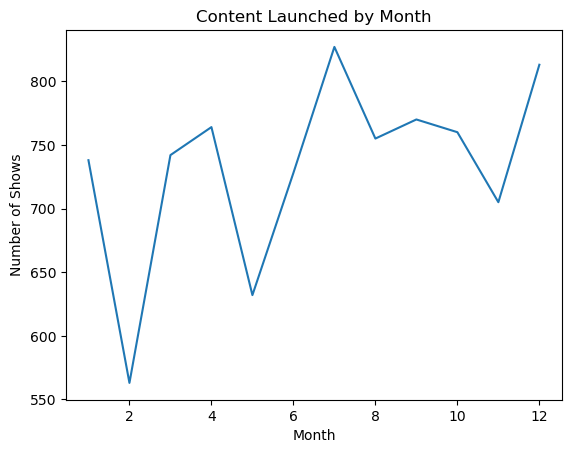

In [56]:
plt.figure()
content_fig= netflix.groupby(['month_added'])['show_id'].count().plot(kind='line')
content_fig.set(title= 'Content Launched by Month', xlabel= 'Month', ylabel= 'Number of Shows')

[Text(0.5, 0, 'Season'),
 Text(0, 0.5, 'Number of shows'),
 Text(0.5, 1.0, 'Content Launched by Season')]

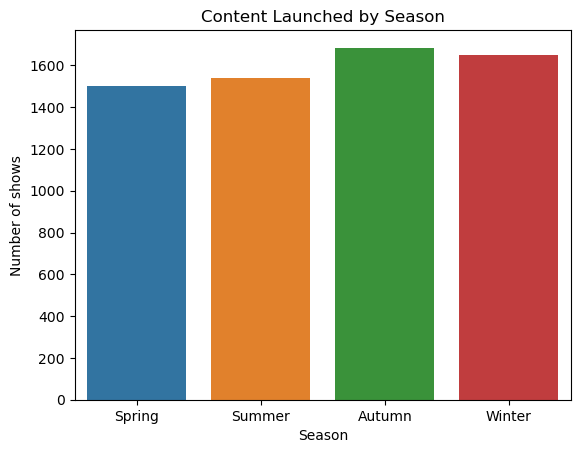

In [57]:
plt.figure()
sns_season_fig =sns.countplot(data=msk_top5, x='season', order=['Spring', 'Summer', 'Autumn', 'Winter'])
sns_season_fig.set(xlabel ="Season", ylabel = "Number of shows", title ='Content Launched by Season')

[Text(0.5, 0, 'Type'),
 Text(0, 0.5, 'Count'),
 Text(0.5, 1.0, 'Types of Content Available on Netflix')]

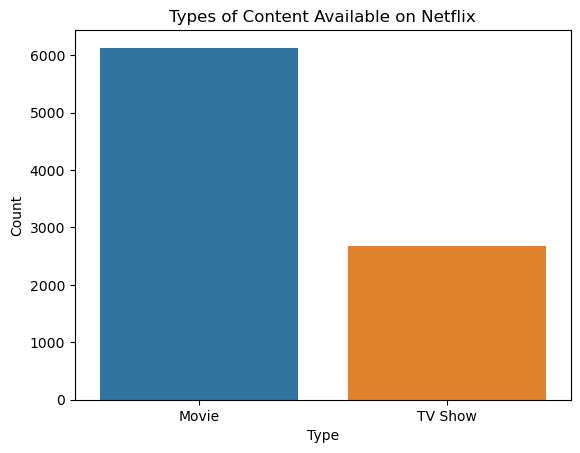

In [59]:
plt.figure()
type_fig = sns.countplot(data=netflix, x='type')
type_fig.set(xlabel ="Type", ylabel = "Count", title ='Types of Content Available on Netflix')

[Text(0.5, 0, 'Type'),
 Text(0, 0.5, 'Count'),
 Text(0.5, 1.0, 'Types of Content Available in the Top 5 Countries')]

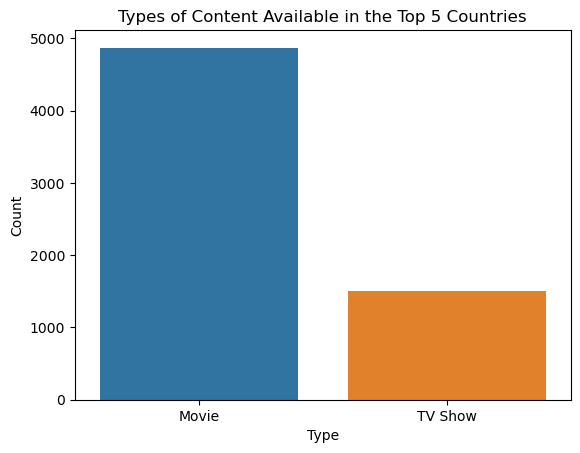

In [60]:
plt.figure()
top5_type_fig = sns.countplot(data=msk_top5, x='type')
top5_type_fig.set(xlabel ="Type", ylabel = "Count", title ='Types of Content Available in the Top 5 Countries')

C:\Users\ASUS\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


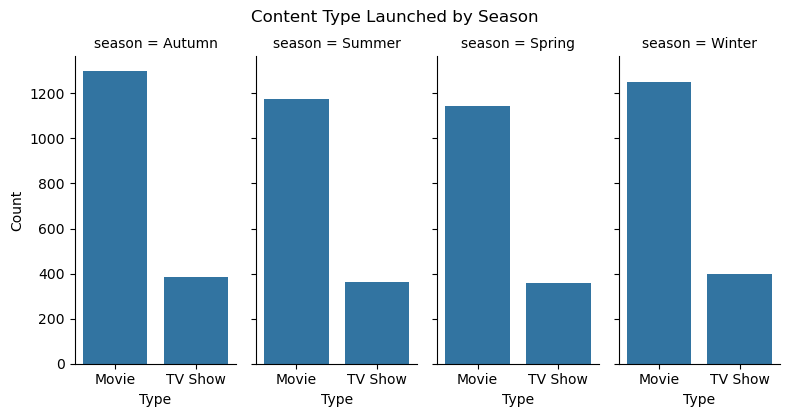

In [61]:
season_type_fig =  sns.FacetGrid(data= msk_top5, col = "season", 
                    height = 4, aspect  =.5)
season_type_fig.map(sns.countplot, "type", order = ['Movie', 'TV Show'],)
season_type_fig.fig.suptitle('Content Type Launched by Season', y=1.03)
season_type_fig.set(xlabel='Type', ylabel='Count')

In [62]:
netflix.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  can           8807 non-null   bool          
 13  ind           8807 non-null   bool          
 14  US            8807 non-null   bool          
 15  UK            8807 non-null   bool    